 # Energy Agent — EDA + Anomaly Detection Groundwork
 Milestone 1, Week 1 Days 5-7 (compressed).
 Data: real BDG2 electricity readings (5 buildings, 2016-2017, hourly) +
 synthetic water/HVAC-lighting-equipment split + injected labeled anomalies.
 Run cells top to bottom with VS Code's Jupyter extension (Ctrl+Enter per cell).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (12, 4)

facilities = pd.read_csv("../data/raw/facilities.csv")
energy = pd.read_csv("../data/raw/energy_usage.csv", parse_dates=["timestamp"])

print(facilities)
print(f"\n{len(energy):,} rows | {energy['timestamp'].min()} to {energy['timestamp'].max()}")
print(f"Anomaly rate: {energy['is_anomaly'].mean()*100:.2f}%")

   facility_id              facility_name      facility_type     location
0            1      Panther office Hannah   Corporate Office   US/Eastern
1            2          Fox office Israel            IT Park  US/Mountain
2            3  Panther education Teofila  University Campus   US/Eastern
3            4       Bear education Lidia  University Campus   US/Pacific
4            5        Eagle health Athena           Hospital   US/Eastern

87,677 rows | 2016-01-01 00:00:00 to 2017-12-31 23:00:00
Anomaly rate: 1.53%


 ## 1. Basic shape check — nulls, ranges, per-facility row counts
 Real sensor data always has quirks; confirm nothing broke in the loader.

In [ ]:
print(energy.isnull().sum())
print("\nPer-facility row counts:")
print(energy.groupby("facility_id").size())
print("\nElectricity usage range:")
print(energy["electricity_usage"].describe())

energy_id            0
facility_id          0
timestamp            0
electricity_usage    0
water_usage          0
hvac_kw              0
lighting_kw          0
equipment_kw         0
is_anomaly           0
dtype: int64

Per-facility row counts:
facility_id
1    17539
2    17544
3    17540
4    17510
5    17544
dtype: int64

Electricity usage range:
count    87677.000000
mean       114.888060
std        143.028400
min          0.000000
25%          8.000000
50%         88.440000
75%        166.324100
max       1874.371406
Name: electricity_usage, dtype: float64


 ## 2. Daily consumption pattern — is the occupancy signal visible?
 Real office/education buildings should show a clear 9-to-5 weekday curve.

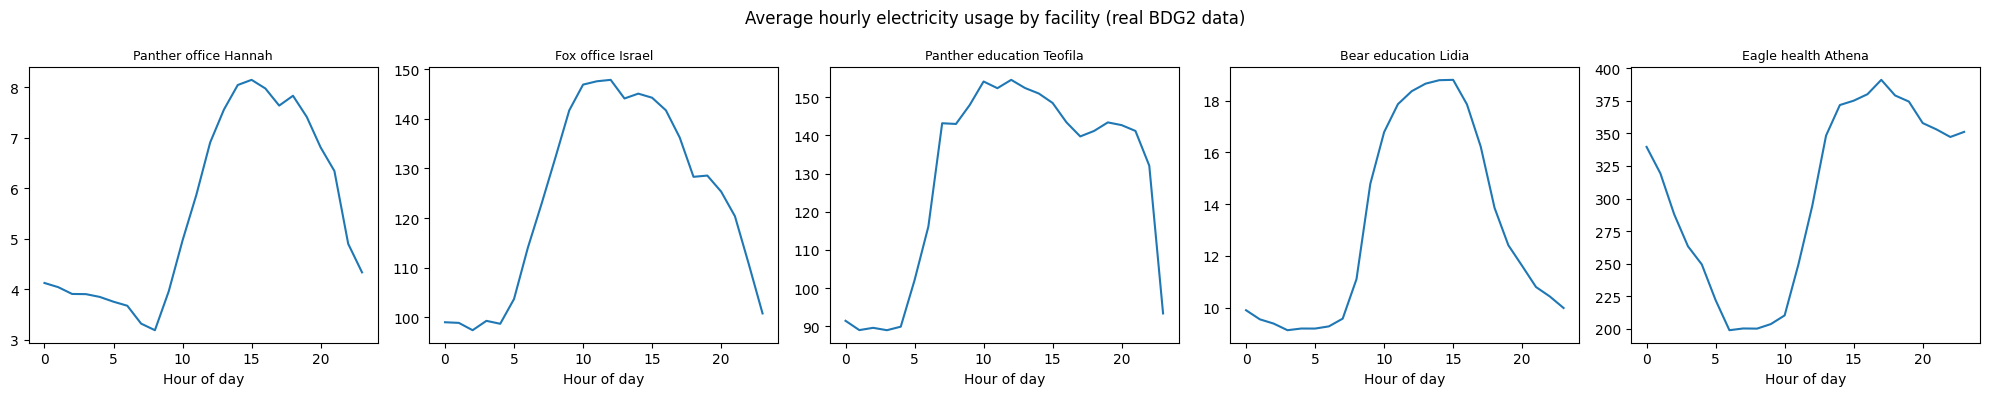

In [ ]:
energy["hour"] = energy["timestamp"].dt.hour
energy["weekday"] = energy["timestamp"].dt.day_name()
energy["is_weekend"] = energy["timestamp"].dt.weekday >= 5

fig, axes = plt.subplots(1, len(facilities), figsize=(20, 4), sharey=False)
for ax, (_, fac) in zip(axes, facilities.iterrows()):
    subset = energy[energy["facility_id"] == fac["facility_id"]]
    hourly_avg = subset.groupby("hour")["electricity_usage"].mean()
    ax.plot(hourly_avg.index, hourly_avg.values)
    ax.set_title(fac["facility_name"], fontsize=9)
    ax.set_xlabel("Hour of day")
plt.suptitle("Average hourly electricity usage by facility (real BDG2 data)")
plt.tight_layout()
plt.savefig("../data/processed/daily_pattern_by_facility.png", dpi=100)
plt.show()

 ## 3. Weekday vs weekend — confirms real occupancy-driven behavior

In [ ]:
weekday_compare = energy.groupby(["facility_id", "is_weekend"])["electricity_usage"].mean().unstack()
weekday_compare.columns = ["Weekday", "Weekend"]
weekday_compare["Weekend/Weekday ratio"] = weekday_compare["Weekend"] / weekday_compare["Weekday"]
print(weekday_compare.round(2))

             Weekday  Weekend  Weekend/Weekday ratio
facility_id                                         
1               5.87     4.66                   0.79
2             131.51   105.31                   0.80
3             131.27   122.69                   0.93
4              14.43     9.69                   0.67
5             318.00   265.26                   0.83


 ## 4. Seasonal trend — full 2-year real range lets us actually see this
 (Synthetic data faked this with a sine wave; here it's genuine weather-driven HVAC load.)

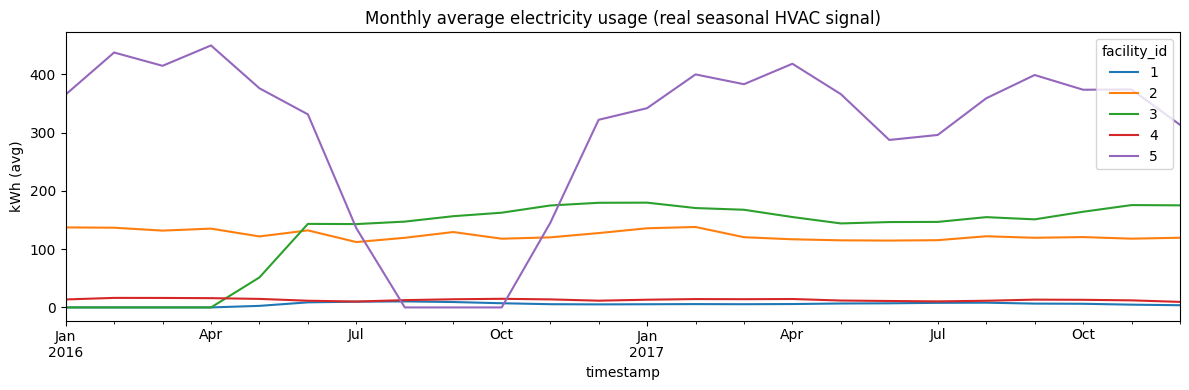

In [ ]:
monthly = energy.set_index("timestamp").groupby("facility_id").resample("ME")["electricity_usage"].mean()
monthly = monthly.unstack(level=0)
monthly.plot(title="Monthly average electricity usage (real seasonal HVAC signal)")
plt.ylabel("kWh (avg)")
plt.tight_layout()
plt.savefig("../data/processed/seasonal_trend.png", dpi=100)
plt.show()

 ## 5. What do the labeled anomalies actually look like?
 Sanity check before trusting them as ground truth for the detector.

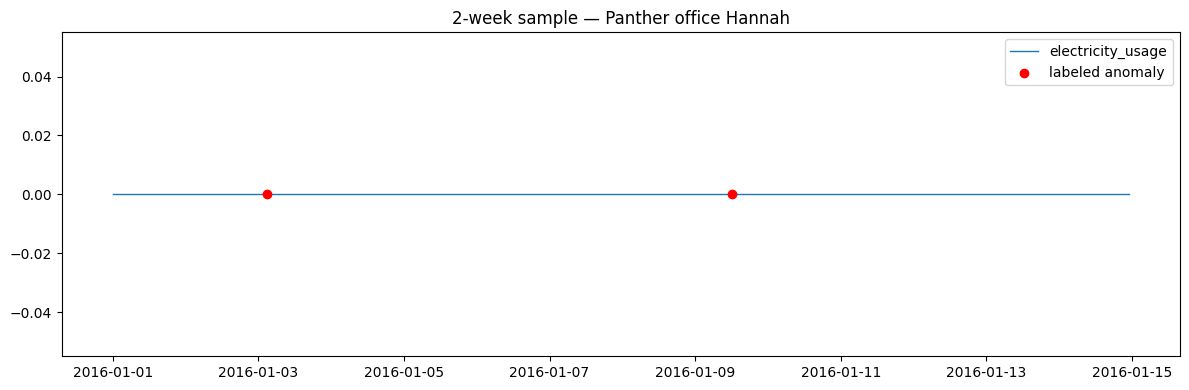

In [ ]:
sample_facility = facilities["facility_id"].iloc[0]
subset = energy[(energy["facility_id"] == sample_facility)].sort_values("timestamp").iloc[:24 * 14]  # 2 weeks

fig, ax = plt.subplots()
ax.plot(subset["timestamp"], subset["electricity_usage"], label="electricity_usage", linewidth=1)
anomalies = subset[subset["is_anomaly"]]
ax.scatter(anomalies["timestamp"], anomalies["electricity_usage"], color="red", zorder=5, label="labeled anomaly")
ax.set_title(f"2-week sample — {facilities.loc[facilities['facility_id']==sample_facility, 'facility_name'].iloc[0]}")
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/anomaly_sample.png", dpi=100)
plt.show()

 ## 6. Feature engineering for the anomaly detector
 Isolation Forest needs numeric features that capture "is this reading unusual
 given the recent pattern" — not just the raw value (a real 500kW reading might
 be normal for a hospital and anomalous for a small office).

In [ ]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(["facility_id", "timestamp"]).copy()
    df["hour"] = df["timestamp"].dt.hour
    df["weekday_num"] = df["timestamp"].dt.weekday
    df["is_weekend"] = (df["weekday_num"] >= 5).astype(int)

    # Rolling baseline per facility: how far is this reading from its own recent norm?
    grp = df.groupby("facility_id")["electricity_usage"]
    df["rolling_mean_24h"] = grp.transform(lambda s: s.rolling(24, min_periods=1).mean())
    df["rolling_std_24h"] = grp.transform(lambda s: s.rolling(24, min_periods=1).std().fillna(0))
    df["deviation_from_baseline"] = (
        (df["electricity_usage"] - df["rolling_mean_24h"]) / df["rolling_std_24h"].replace(0, 1)
    )
    return df

featured = build_features(energy)
feature_cols = ["electricity_usage", "hour", "weekday_num", "is_weekend", "deviation_from_baseline"]
print(featured[feature_cols + ["is_anomaly"]].describe())

       electricity_usage          hour   weekday_num    is_weekend  \
count       87677.000000  87677.000000  87677.000000  87677.000000   
mean          114.888060     11.500017      3.008759      0.287419   
std           143.028400      6.921474      2.000927      0.452561   
min             0.000000      0.000000      0.000000      0.000000   
25%             8.000000      6.000000      1.000000      0.000000   
50%            88.440000     12.000000      3.000000      0.000000   
75%           166.324100     17.000000      5.000000      1.000000   
max          1874.371406     23.000000      6.000000      1.000000   

       deviation_from_baseline  
count             87677.000000  
mean                  0.010553  
std                   0.987521  
min                  -4.479012  
25%                  -0.726521  
50%                   0.000000  
75%                   0.576604  
max                   4.694856  


 ## 7. Quick look — does `deviation_from_baseline` alone separate anomalies?
 If yes, Isolation Forest on these features should hit the >=85% target easily.

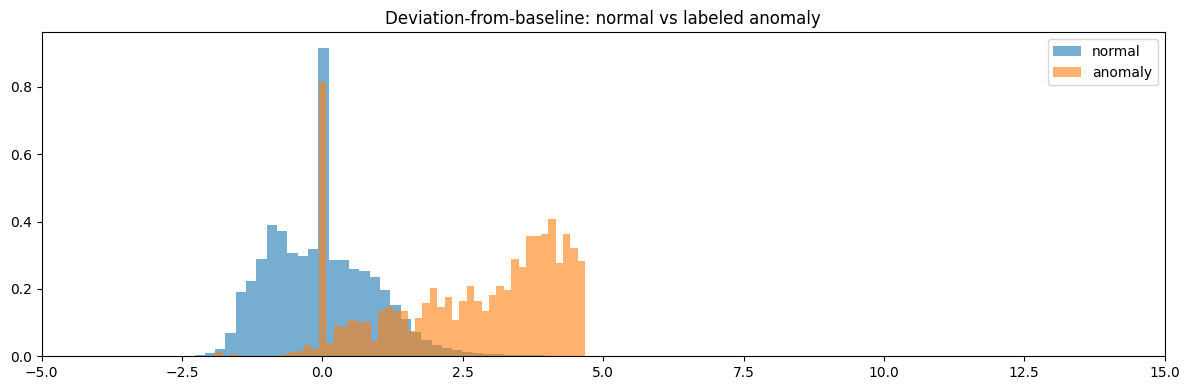

In [ ]:
fig, ax = plt.subplots()
ax.hist(featured.loc[~featured["is_anomaly"], "deviation_from_baseline"], bins=50, alpha=0.6, label="normal", density=True)
ax.hist(featured.loc[featured["is_anomaly"], "deviation_from_baseline"], bins=50, alpha=0.6, label="anomaly", density=True)
ax.set_xlim(-5, 15)
ax.legend()
ax.set_title("Deviation-from-baseline: normal vs labeled anomaly")
plt.tight_layout()
plt.savefig("../data/processed/deviation_separation.png", dpi=100)
plt.show()

 ## Save the featured dataset for the agent module to consume directly
 (Avoids recomputing features twice — src/agents/energy_agent.py will import this shape.)

In [ ]:
featured.to_csv("../data/processed/energy_featured.csv", index=False)
print(f"Saved {len(featured):,} rows -> data/processed/energy_featured.csv")
print("\nReady to build src/agents/energy_agent.py using these features.")

Saved 87,677 rows -> data/processed/energy_featured.csv

Ready to build src/agents/energy_agent.py using these features.
